# Transcript/Question Prompt Generation

In [15]:
from testing_framework import *

stepwise_transcripts = pd.read_csv('./csv/stepwise_transcripts.csv')

truncated = stepwise_transcripts[8 <= stepwise_transcripts['num_ings']][16 > stepwise_transcripts['num_ings']][stepwise_transcripts['transcript'].notna()]

# seed = 42

def df_from_actor_specs(name, pronoun, c, p, ir):
    df = {
        'id': [],
        'transcript': []
    }

    for i, t in enumerate(truncated['transcript']):
        actor = Actor(name, pronoun, c, p, ir)
        transcript = actor.run_recipe(eval(t))
        df['id'].append(truncated.iloc[:, 0].iloc[i])
        df['transcript'].append(transcript)

    df = pd.DataFrame(df)
    df.set_index('id', inplace=True)
    df.to_csv(f'./results/{name}({pronoun})_c{c}_p{p}_i{ir}.csv')


def single_actor_prompt(name, n_samples, c, p, ir, ic_ex=True):
    actor = Actor(name, random.choice(['he', 'she', 'they']), c, p, ir)
    question_prompt = ''

    def get_transcript_with_mistake():
        transcript_with_mistake = ''
        transcript_row = None
        while 'mistake' not in transcript_with_mistake:
            transcript_row = truncated.sample(1)
            recipe = transcript_row['transcript'].item()
            transcript_with_mistake = actor.run_recipe(eval(recipe))
            # print(transcript_with_mistake)
        recipe_title = transcript_row['title'].item()

        return transcript_with_mistake, recipe_title

    if ic_ex:
        question_prompt = f'Below are a set of transcripts describing {name} cooking various recipes, seperated by asterisks:\n'
        question_prompt += '*' * 5 + '\n'

        for i in range(n_samples):
            transcript, title = get_transcript_with_mistake()

            question_prompt += f'{name} attempts to make the recipe "{title}".\n'
            question_prompt += transcript
            if 'give up' not in transcript: question_prompt += f'{name} finishes making the recipe.\n'
            question_prompt += '*' * 5 + '\n'

    question_prompt += '\n'
    transcript, title = get_transcript_with_mistake()
    question_prompt += f'Below is an incomplete transcript of {name} making the recipe "{title}":\n'

    for line in transcript.split('\n'):
        question_prompt += line + '\n'
        if 'mistake' in line: break

    question_prompt += '\n'
    question_prompt += f'Given the following options, which option best represents how {name} will react?\n'
    question_prompt += 'Option 1: fix the mistake\n'
    question_prompt += 'Option 2: ignore the mistake\n'
    question_prompt += 'Option 3: give up\n\n'

    question_prompt += '\n'

    return actor, question_prompt


def evil_actor_prompt(name, n_samples, c, p, ir, ic_ex=True):
    actor = Actor(name, random.choice(['he', 'she', 'they']), c, p, ir)
    evil_actor = Actor('Person A', random.choice(['he', 'she', 'they']), c, 1-p, 1-ir)
    question_prompt = ''

    def get_transcript_with_mistake(a):
        transcript_with_mistake = ''
        transcript_row = None
        while 'mistake' not in transcript_with_mistake:
            transcript_row = truncated.sample(1)
            recipe = transcript_row['transcript'].item()
            transcript_with_mistake = a.run_recipe(eval(recipe))
            # print(transcript_with_mistake)
        recipe_title = transcript_row['title'].item()

        return transcript_with_mistake, recipe_title

    if ic_ex:
        question_prompt = f'Below are a set of transcripts describing Person 0 cooking various recipes, seperated by asterisks:\n'
        question_prompt += '*' * 5 + '\n'

        for i in range(n_samples):
            transcript, title = get_transcript_with_mistake(evil_actor)

            question_prompt += f'Person A attempts to make the recipe "{title}".\n'
            question_prompt += transcript
            if 'give up' not in transcript: question_prompt += f'Person A finishes making the recipe.\n'
            question_prompt += '*' * 5 + '\n'

    question_prompt += '\n'
    transcript, title = get_transcript_with_mistake(actor)
    question_prompt += f'Below is an incomplete transcript of {name} making the recipe "{title}":\n'

    for line in transcript.split('\n'):
        question_prompt += line + '\n'
        if 'mistake' in line: break

    question_prompt += '\n'
    question_prompt += f'Given the following options, which option best represents how {name} will react?\n'
    question_prompt += 'Option 1: fix the mistake\n'
    question_prompt += 'Option 2: ignore the mistake\n'
    question_prompt += 'Option 3: give up\n\n'

    question_prompt += '\n'

    return actor, question_prompt


def multi_actor_prompt(name, n_samples, c, p, ir, ic_ex=True):
    actor = Actor(name, random.choice(['he', 'she', 'they']), c, p, ir)
    question_prompt = ''

    def get_transcript_with_mistake(a):
        transcript_with_mistake = ''
        transcript_row = None
        while 'mistake' not in transcript_with_mistake:
            transcript_row = truncated.sample(1)
            recipe = transcript_row['transcript'].item()
            transcript_with_mistake = a.run_recipe(eval(recipe))
            # print(transcript_with_mistake)
        recipe_title = transcript_row['title'].item()

        return transcript_with_mistake, recipe_title

    if ic_ex:
        question_prompt = f'Below are a set of transcripts describing Person A cooking various recipes, seperated by asterisks:\n'
        question_prompt += '*' * 5 + '\n'

        for i in range(n_samples):
            letters = ['A','B','C','D','E']
            a = Actor(f'Person {letters[i]}', random.choice(['he', 'she', 'they']), c, random.choice(list(range(3,8)))/10, random.choice(list(range(3,8)))/10)
            transcript, title = get_transcript_with_mistake(a)

            question_prompt += f'Person {letters[i]} attempts to make the recipe "{title}".\n'
            question_prompt += transcript
            if 'give up' not in transcript: question_prompt += f'Person A finishes making the recipe.\n'
            question_prompt += '*' * 5 + '\n'

    question_prompt += '\n'
    transcript, title = get_transcript_with_mistake(actor)
    question_prompt += f'Below is an incomplete transcript of {name} making the recipe "{title}":\n'

    for line in transcript.split('\n'):
        question_prompt += line + '\n'
        if 'mistake' in line: break

    question_prompt += '\n'
    question_prompt += f'Given the following options, which option best represents how {name} will react?\n'
    question_prompt += 'Option 1: fix the mistake\n'
    question_prompt += 'Option 2: restart the recipe\n'
    question_prompt += 'Option 3: give up\n\n'

    question_prompt += '\n'

    return actor, question_prompt


def multi_actor_prompt(name, n_samples, c, p, ir, ic_ex=True):
    actor = Actor(name, random.choice(['he', 'she', 'they']), c, p, ir)
    question_prompt = ''

    def get_transcript_with_mistake(a):
        transcript_with_mistake = ''
        transcript_row = None
        while 'mistake' not in transcript_with_mistake:
            transcript_row = truncated.sample(1)
            recipe = transcript_row['transcript'].item()
            transcript_with_mistake = a.run_recipe(eval(recipe))
            # print(transcript_with_mistake)
        recipe_title = transcript_row['title'].item()

        return transcript_with_mistake, recipe_title

    if ic_ex:
        question_prompt = f'Below are a set of transcripts describing Person A cooking various recipes, seperated by asterisks:\n'
        question_prompt += '*' * 5 + '\n'

        for i in range(n_samples):
            letters = ['A','B','C','D','E']
            a = Actor(f'Person {letters[i]}', random.choice(['he', 'she', 'they']), c, p, ir)
            transcript, title = get_transcript_with_mistake(a)

            question_prompt += f'Person {letters[i]} attempts to make the recipe "{title}".\n'
            question_prompt += transcript
            if 'give up' not in transcript: question_prompt += f'Person {letters[i]} finishes making the recipe.\n'
            question_prompt += '*' * 5 + '\n'

    question_prompt += '\n'
    transcript, title = get_transcript_with_mistake(actor)
    question_prompt += f'Below is an incomplete transcript of {name} making the recipe "{title}":\n'

    for line in transcript.split('\n'):
        question_prompt += line + '\n'
        if 'mistake' in line: break

    question_prompt += '\n'
    question_prompt += f'Given the following options, which option best represents how {name} will react?\n'
    question_prompt += 'Option 1: fix the mistake\n'
    question_prompt += 'Option 2: restart the recipe\n'
    question_prompt += 'Option 3: give up\n\n'

    question_prompt += '\n'

    return actor, question_prompt

def personality_actor_prompt(name, n_samples, c, p, ir, ic_ex=True):
    actor, question_prompt = multi_actor_prompt(name, n_samples, c, p, ir, ic_ex)
    return actor, question_prompt.replace('Below is an incomplete transcript of', f'All previous people share a similar emotional profile with {name}. \nBelow is an incomplete transcript of')


print(personality_actor_prompt('Person 1', 5, 0.8, 0.6, 0.4)[1])




Below are a set of transcripts describing Person A cooking various recipes, seperated by asterisks:
*****
Person A attempts to make the recipe "Winter Squash and Lentil Bisque".
Person A heats 2 medium butternut squash or 2 medium acorn squash, 2 medium green apples or 2 cups green apples, 1 medium red onion, 12 cup unsweetened applesauce, 1 cup apple juice, 14 teaspoon ground nutmeg, 18 teaspoon ground red pepper (Cayenne) and 3 (14 ounce) cans vegetable broth, producing some mixture.
Person A place the mixture, producing some squash mixture in blender.
Person A blend mixture and squash mixture in blender, producing some smooth mixture.
Person A stirs 12 cup dried lentils and smooth mixture, producing some mixture.
Person A simmer the mixture, producing some simmered mixture.
Person A sprinkles 34 cup shredded reduced-fat mozzarella cheese or 3 ounces reduced-fat mozzarella cheese and 6 slices French bread (1/4 inch thick), producing some topped bread.
Person A place mixture and broil

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_59845/57650579.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[8 <= stepwise_transcripts['num_ings']][16 > stepwise_transcripts['num_ings']][stepwise_transcripts['transcript'].notna()]
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_59845/57650579.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[8 <= stepwise_transcripts['num_ings']][16 > stepwise_transcripts['num_ings']][stepwise_transcripts['transcript'].notna()]


In [5]:
def run_prompt_actor(actor,
               prompt,
               test_name,
               metadata_index,
               num_samples = 20):

    result = test_next_action(prompt, num_samples)

    outputs, full_outputs = result

    dataroot = f'./results/n{num_samples}_n5_{test_name}'

    try: os.mkdir(dataroot)
    except OSError as e: pass

    try: metadata = pd.read_csv(dataroot + '/metadata.csv')
    except: metadata = pd.DataFrame(columns=['actor', 'prompt'])

    out_df = pd.DataFrame(outputs)
    full_df = pd.DataFrame(full_outputs)
    metadata.loc[len(metadata)] = [actor, prompt]

    out_df.to_csv(f'{dataroot}/outputs{metadata_index}.csv', index=False)
    full_df.to_csv(f'{dataroot}/full_outputs{metadata_index}.csv', index=False)
    metadata.to_csv(f'{dataroot}/metadata.csv', index=False)


In [ ]:
for i in range(10):
    # print(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[i])
    actor, prompt = (
        single_actor_prompt(f'Person {i+1}', 5, 0.8, random.choice(list(range(2,8)))/10, random.choice(list(range(2,8)))/10))
    run_prompt_actor(actor, prompt, 'same_ic', i)

In [16]:
for i in range(5):
    # print(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[i])
    actor, prompt = (
        evil_actor_prompt(f'Person {i+6}', 5, 0.8, random.choice(list(range(2,8)))/10, random.choice(list(range(2,8)))/10))
    run_prompt_actor(actor, prompt, 'inverse_ic', i+5)

 10%|█         | 2/20 [08:01<1:21:58, 273.24s/it]

Error: Error code: 503 - {'id': 'otv6jmN-3pDw3Z-a2233d2b3a142c47', 'error': {'message': 'Service unavailable', 'type': 'service_unavailable', 'param': None, 'code': None}} (Qwen/Qwen3.5-9B)


 15%|█▌        | 3/20 [15:32<1:40:29, 354.65s/it]

Error: Error code: 500 - {'id': 'otv8Vrx-3pDw3Z-a223458dbfbe787f', 'error': {'message': 'Internal server error', 'type': 'server_error', 'param': None, 'code': None}} (Qwen/Qwen3.5-9B)


 65%|██████▌   | 13/20 [32:23<16:29, 141.29s/it] 

Error: Error code: 503 - {'id': 'otvUf9G-3pDw3Z-a223a594cb2d208c', 'error': {'message': 'Service unavailable', 'type': 'service_unavailable', 'param': None, 'code': None}} (Qwen/Qwen3.5-9B)


100%|██████████| 20/20 [51:18<00:00, 153.91s/it] 


In [17]:
for i in range(10):
    # print(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[i])
    actor, prompt = (
        multi_actor_prompt(f'Person {i+1}', 5, 0.8, random.choice(list(range(2,8)))/10, random.choice(list(range(2,8)))/10))
    run_prompt_actor(actor, prompt, 'multi_ic', i)

 80%|████████  | 16/20 [54:38<21:03, 315.95s/it] 

Error: Error code: 500 - {'id': 'otwL8Ji-3pDw3Z-a2249138ea9f2314', 'error': {'message': 'Internal server error', 'type': 'server_error', 'param': None, 'code': None}} (Qwen/Qwen3.5-9B)


100%|██████████| 20/20 [38:58<00:00, 116.91s/it] 


In [ ]:
for i in range(10):
    # print(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[i])
    actor, prompt = (
        personality_actor_prompt(f'Person {i+1}', 5, 0.8, random.choice(list(range(2,8)))/10, random.choice(list(range(2,8)))/10, ic_ex=False)
    )
    run_prompt_actor(actor, prompt, 'no_ic', i)

 75%|███████▌  | 15/20 [14:20<04:37, 55.57s/it]

[0.8, 0.3, 0.6] {'Option 1': 0.625, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.375} 8
[0.8, 0.7, 0.7] {'Option 1': 0.3333333333333333, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.6666666666666666} 6
[0.8, 0.5, 0.6] {'Option 1': 0.5555555555555556, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.4444444444444444} 9
[0.8, 0.3, 0.7] {'Option 1': 0.625, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.375} 8
[0.8, 0.3, 0.5] {'Option 1': 0.8181818181818182, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.18181818181818182} 11
[0.8, 0.4, 0.7] {'Option 1': 0.8571428571428571, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.14285714285714285} 7
[0.8, 0.7, 0.3] {'Option 1': 0.2857142857142857, 'Option 2': 0, 'Option 3': 0.7142857142857143, 'Option 4': 0.0} 7
[0.8, 0.5, 0.5] {'Option 1': 0.5555555555555556, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.4444444444444444} 9
[0.8, 0.5, 0.6] {'Option 1': 0.5, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.5} 6
[0.8, 0.3, 0.6] {'Option 1': 0.5, 'Option 2'

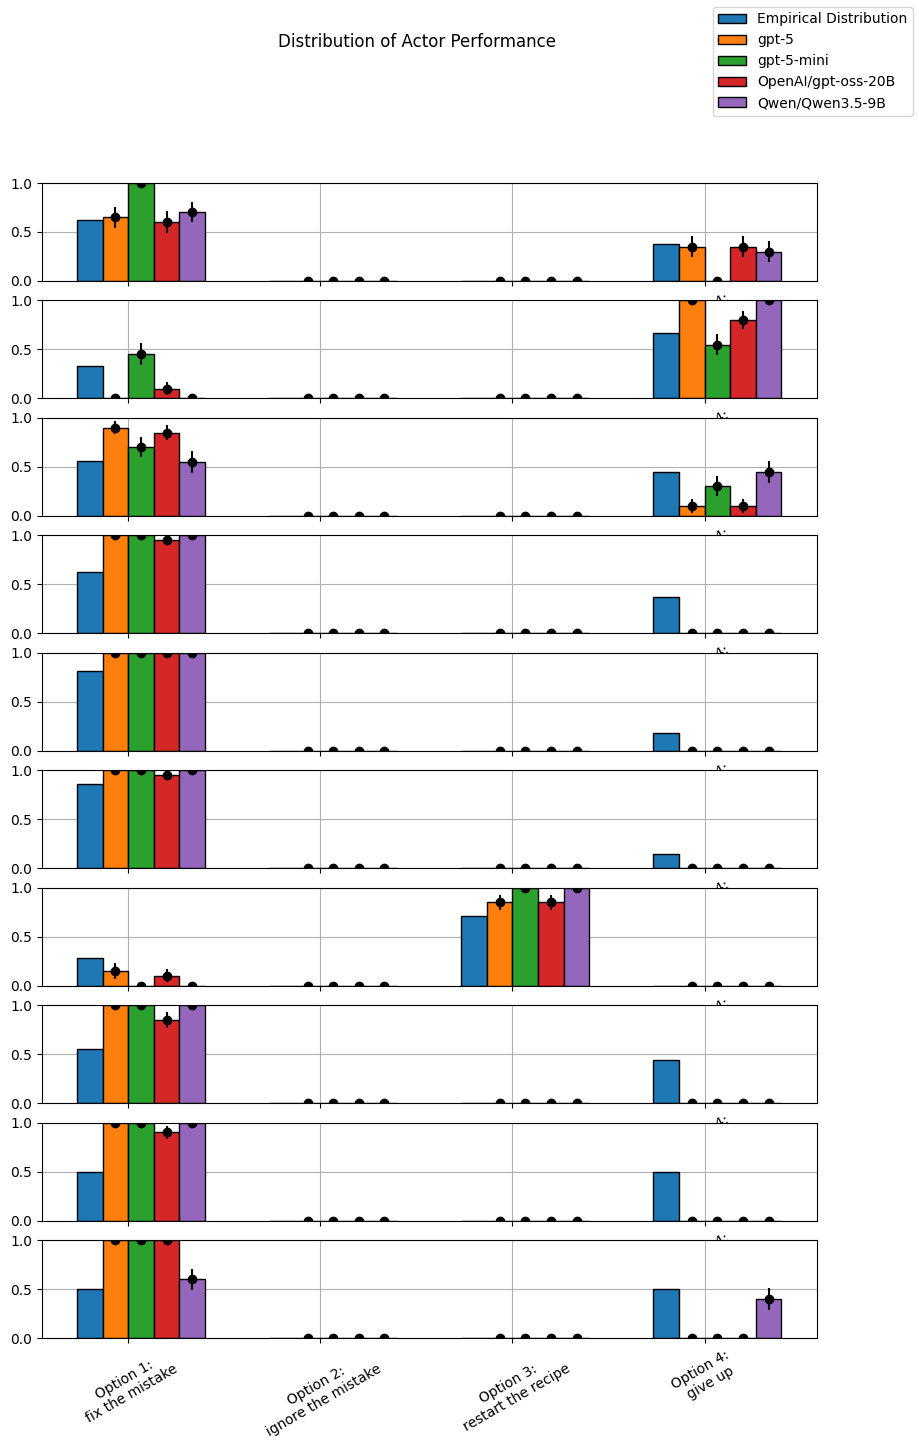

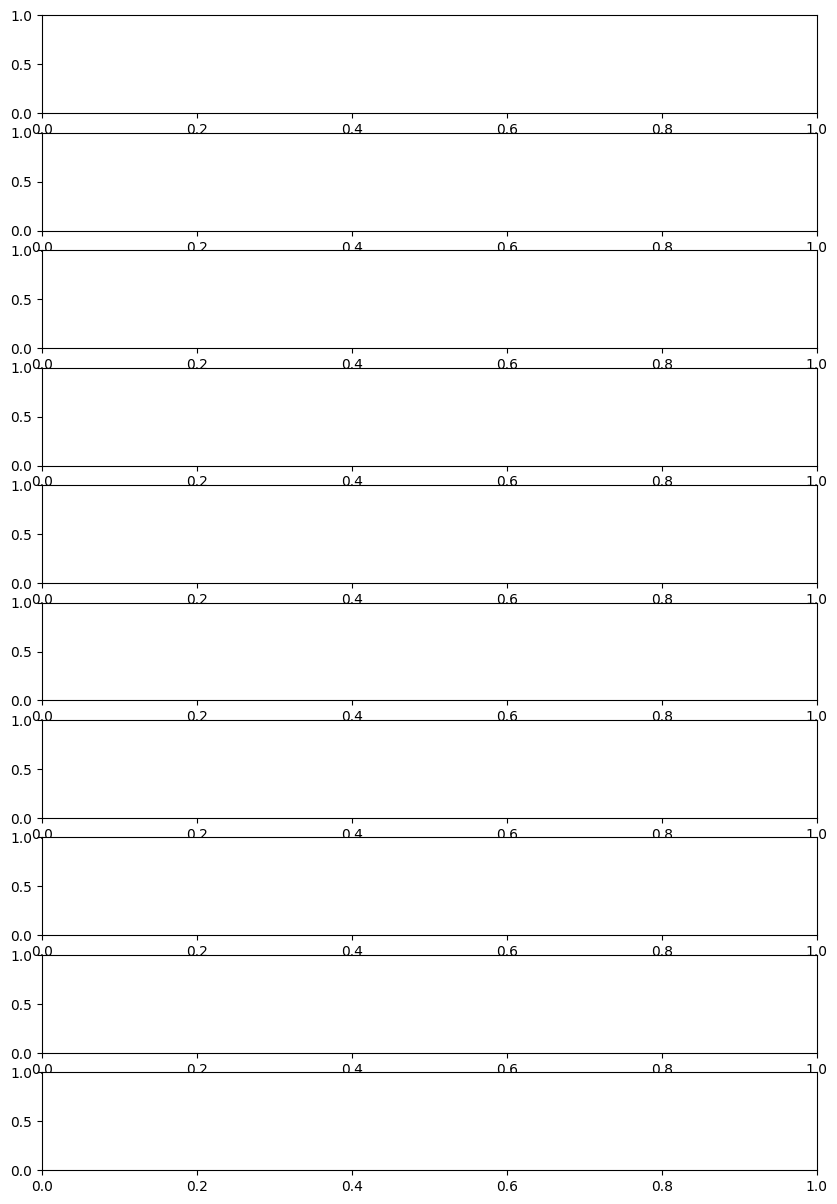

[0.8, 0.5, 0.4] {'Option 1': 0.42857142857142855, 'Option 2': 0, 'Option 3': 0.2857142857142857, 'Option 4': 0.2857142857142857} 7
[0.8, 0.6, 0.7] {'Option 1': 0.5, 'Option 2': 0, 'Option 3': 0.16666666666666666, 'Option 4': 0.3333333333333333} 6
[0.8, 0.5, 0.7] {'Option 1': 0.7777777777777778, 'Option 2': 0, 'Option 3': 0.1111111111111111, 'Option 4': 0.1111111111111111} 9
[0.8, 0.5, 0.6] {'Option 1': 0.4, 'Option 2': 0, 'Option 3': 0.4, 'Option 4': 0.2} 5
[0.8, 0.5, 0.3] {'Option 1': 0.2857142857142857, 'Option 2': 0, 'Option 3': 0.2857142857142857, 'Option 4': 0.42857142857142855} 7
[0.8, 0.7, 0.4] {'Option 1': 0.16666666666666666, 'Option 2': 0, 'Option 3': 0.3333333333333333, 'Option 4': 0.5} 6
[0.8, 0.3, 0.5] {'Option 1': 0.6666666666666666, 'Option 2': 0, 'Option 3': 0.1111111111111111, 'Option 4': 0.2222222222222222} 9
[0.8, 0.4, 0.5] {'Option 1': 0.4, 'Option 2': 0, 'Option 3': 0.6, 'Option 4': 0.0} 5
[0.8, 0.3, 0.4] {'Option 1': 0.5714285714285714, 'Option 2': 0, 'Option 3': 

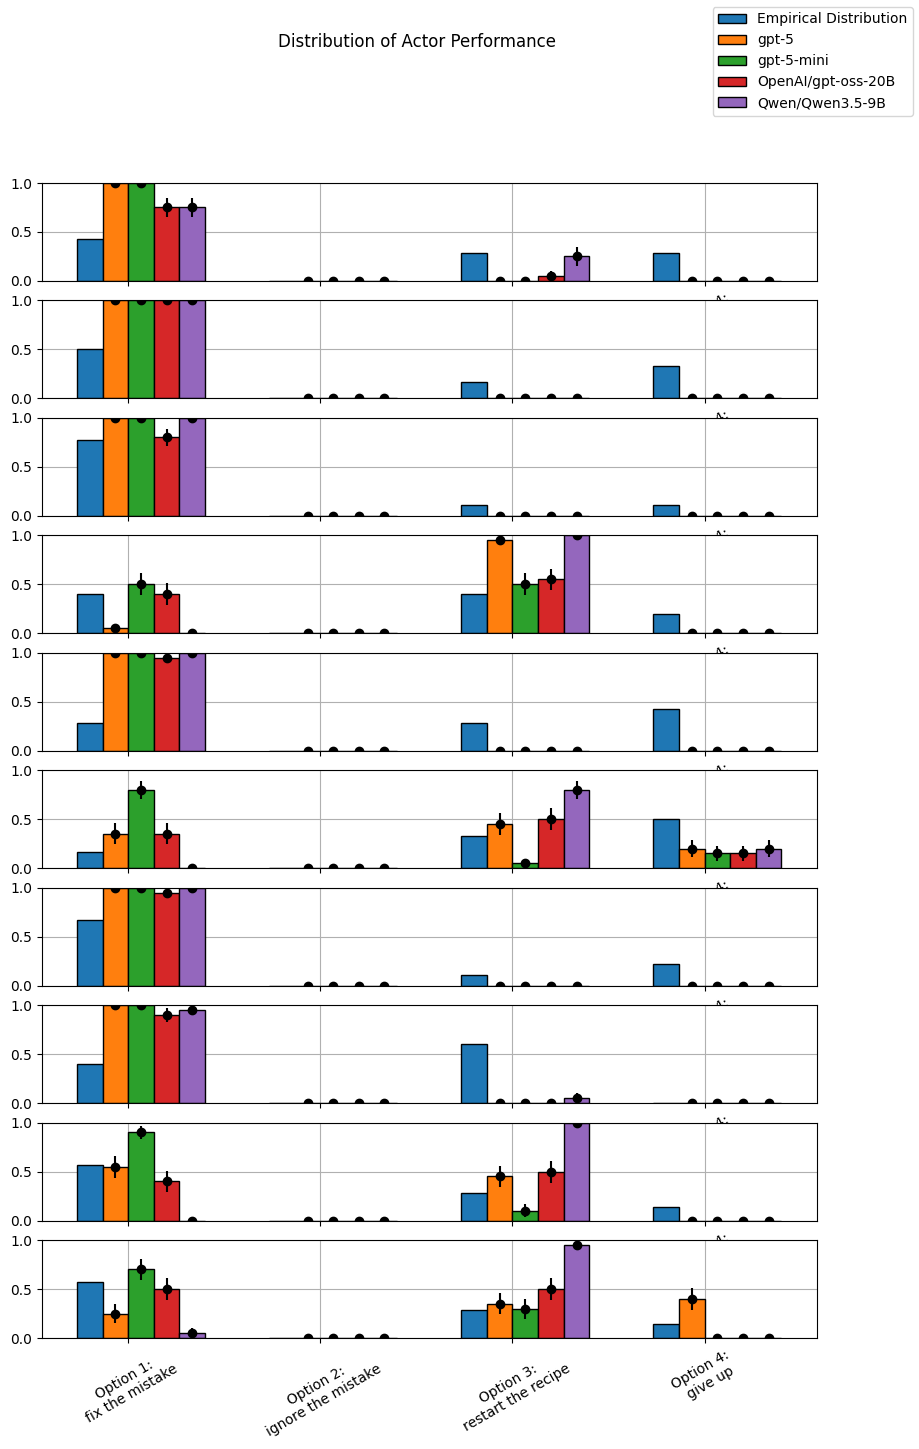

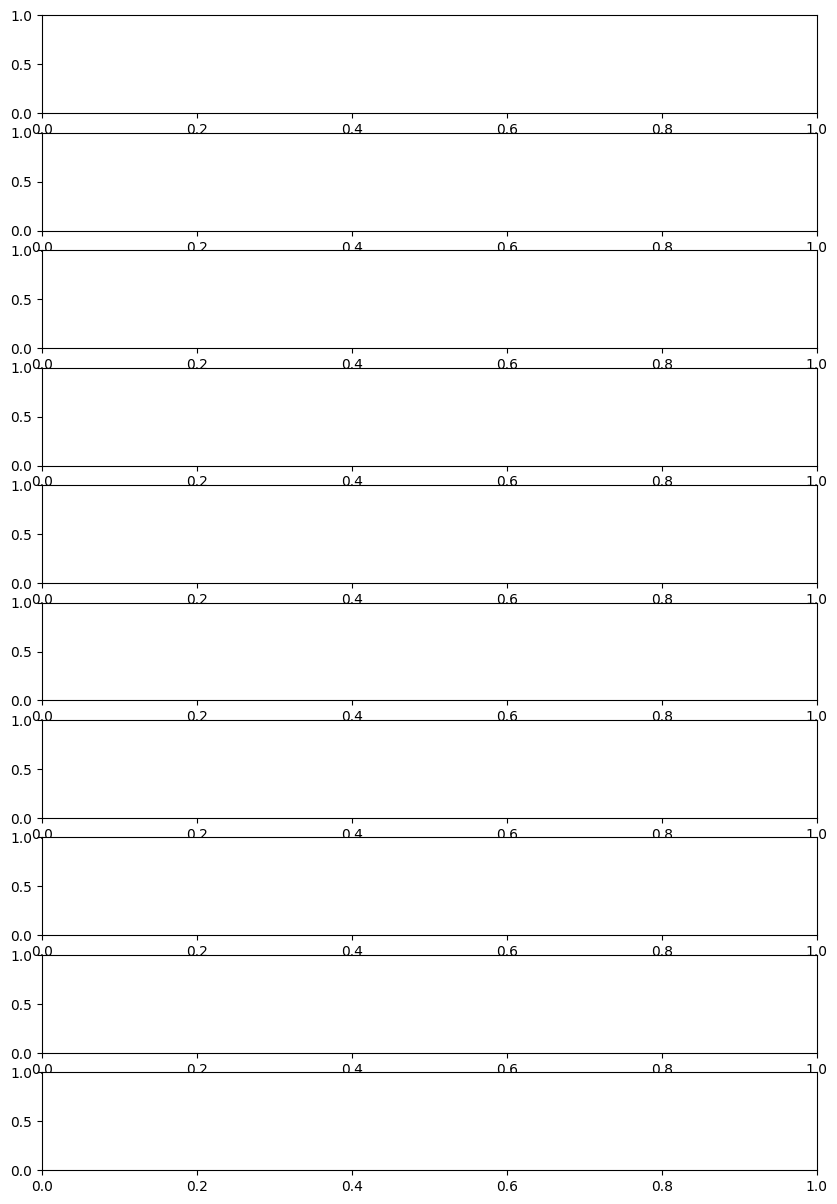

[0.8, 0.6, 0.5] {'Option 1': 0.5, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.5} 8
[0.8, 0.5, 0.4] {'Option 1': 0.3333333333333333, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.6666666666666666} 6
[0.8, 0.5, 0.3] {'Option 1': 0.5714285714285714, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.42857142857142855} 7
[0.8, 0.6, 0.5] {'Option 1': 0.5, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.5} 6
[0.8, 0.3, 0.3] {'Option 1': 0.3333333333333333, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.6666666666666666} 6
[0.8, 0.6, 0.7] {'Option 1': 0.2, 'Option 2': 0, 'Option 3': 0.8, 'Option 4': 0.0} 5
[0.8, 0.7, 0.3] {'Option 1': 0.625, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.375} 8
[0.8, 0.6, 0.3] {'Option 1': 0.5, 'Option 2': 0, 'Option 3': 0.0, 'Option 4': 0.5} 8
[0.8, 0.7, 0.6] {'Option 1': 0.7777777777777778, 'Option 2': 0, 'Option 3': 0.2222222222222222, 'Option 4': 0.0} 9
[0.8, 0.3, 0.6] {'Option 1': 0.2857142857142857, 'Option 2': 0, 'Option 3': 0.7142857142857143, 'Option 4': 0.

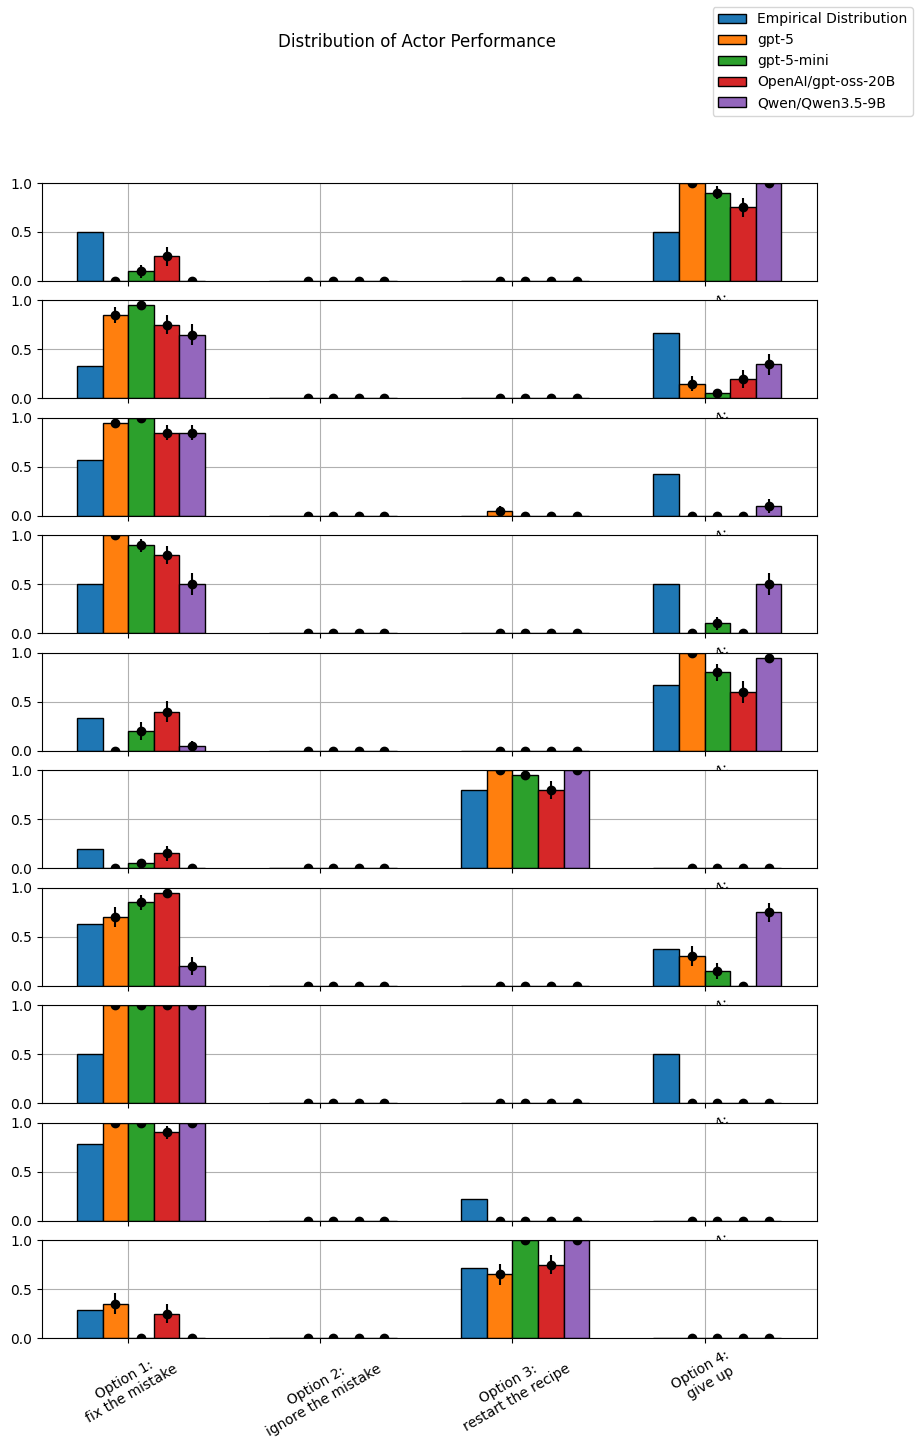

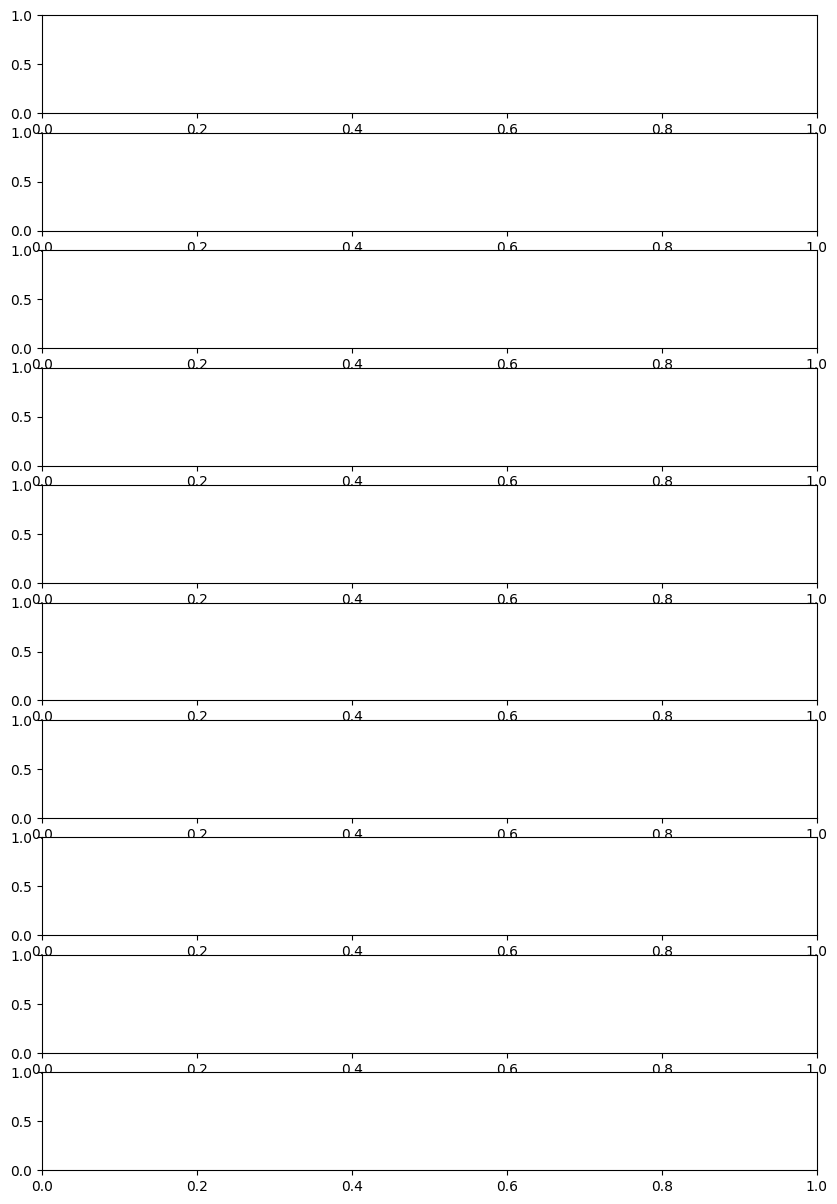

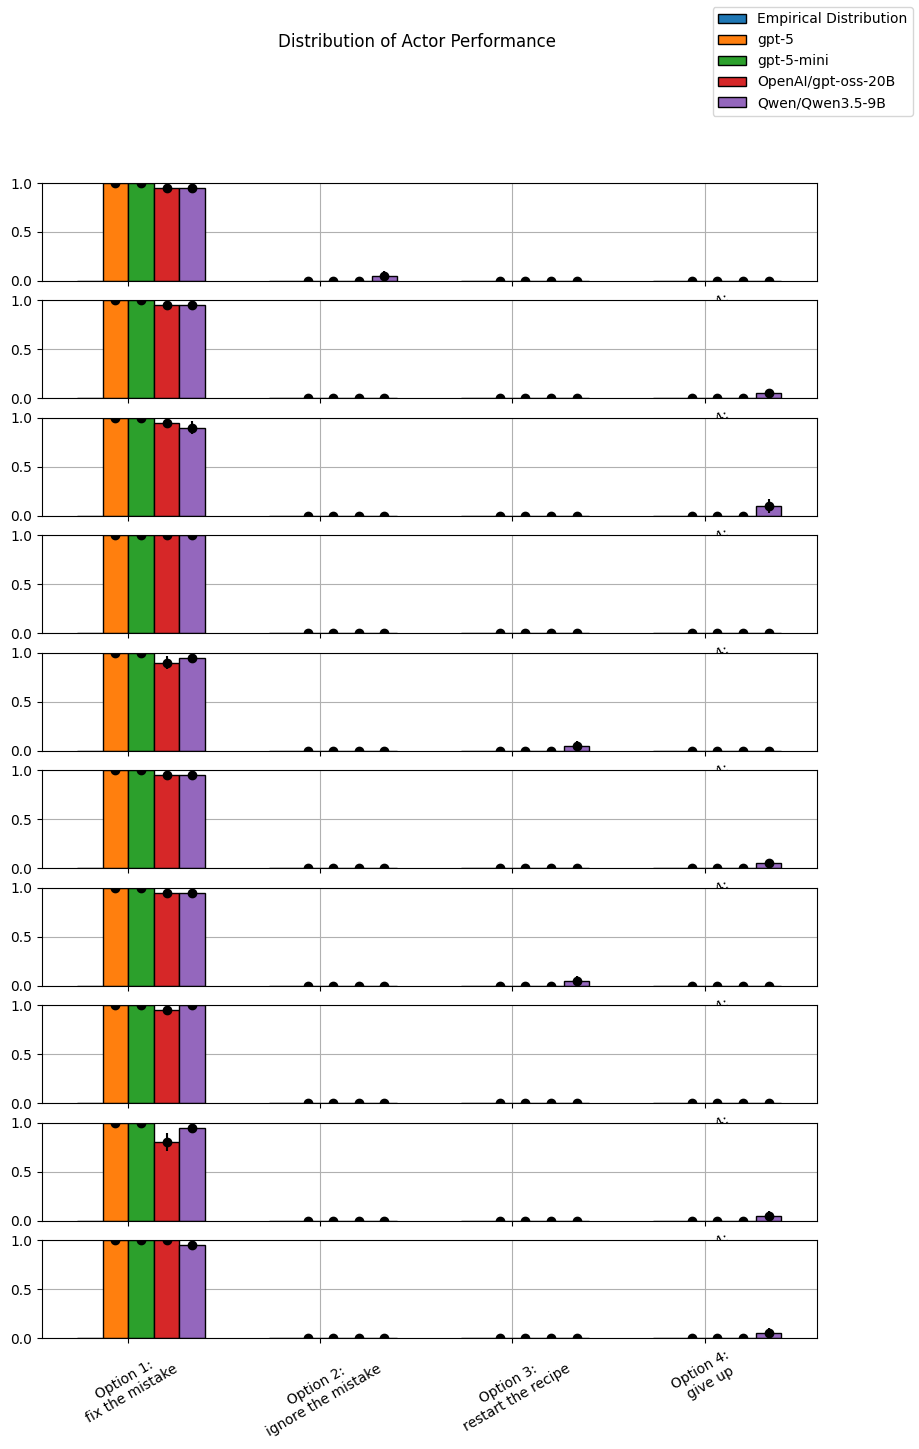

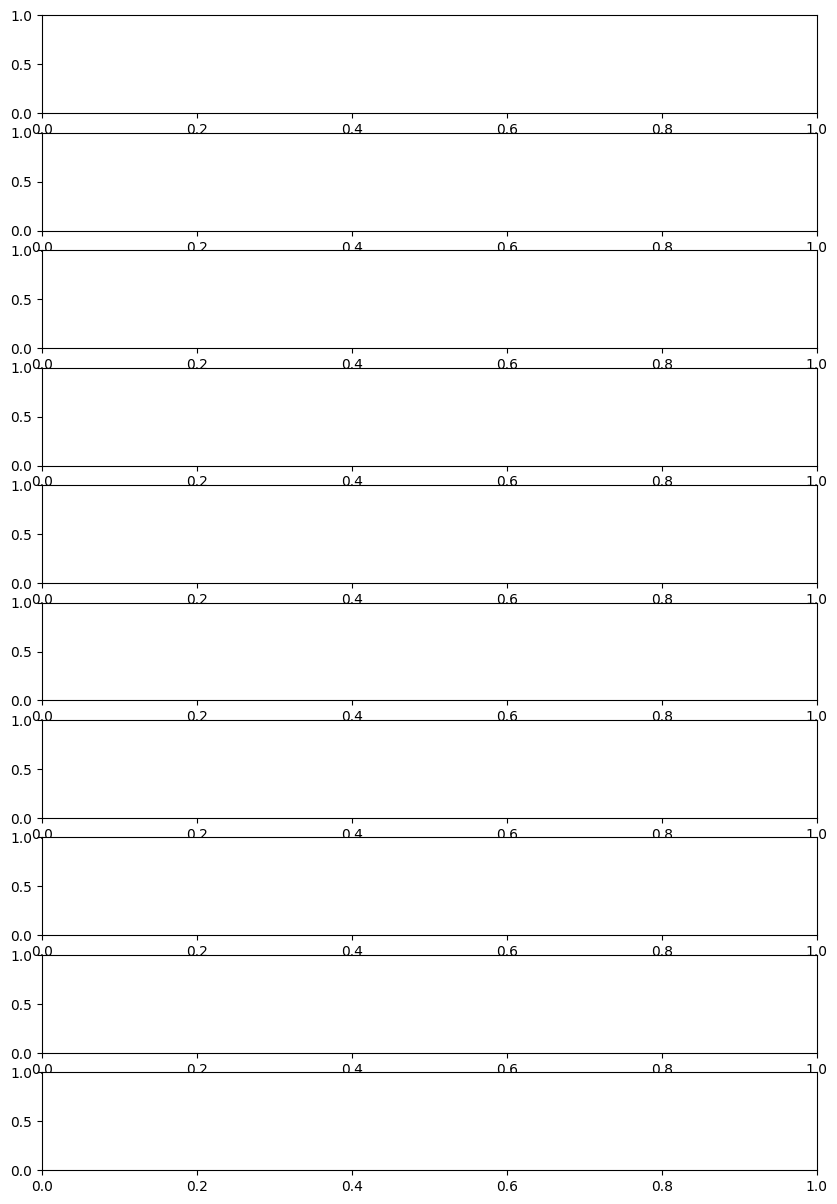

In [89]:
import math
import numpy as np
import matplotlib.pyplot as plt

def distribution(columns):
    dist = {
        'Option 1': [],
        'Option 2': [],
        'Option 3': [],
        'Option 4': []
    }

    for c in columns:
        d = {
            'Option 1': 0,
            'Option 2': 0,
            'Option 3': 0,
            'Option 4': 0
        }

        for response in c:
            res = re.search(r"\d{1} noitpO", response[::-1])
            if res: d[res.group()[::-1]] += 1

        for option in d: dist[option].append(d[option] / len(c))

    mean = {}
    sd = {}
    for option in dist:
        mean[option] = sum(dist[option]) / len(dist[option])
        sd[option] = math.sqrt(mean[option]*(1-mean[option])/len(columns))

    return mean, sd


def get_empirical_distribution_per_actor(test_folder):
    meta_df = pd.read_csv(test_folder+'/metadata.csv')

    full_list = []
    full_list.extend(openai_list)
    full_list.extend(together_list)

    between_scaling = 1.5

    fig, ax = plt.subplots(nrows=len(meta_df), ncols=1, figsize=(10, 15))
    f2, a2 = plt.subplots(nrows=1, ncols=1, figsize=(10, 15))


    for i, row in meta_df.iterrows():
        total = 0
        empirical_dist = {
            'Option 1': 0,
            'Option 2': 0,
            'Option 3': 0,
            'Option 4': 0
        }
        metrics = [float(m.split(' ')[-1]) for m in row['actor'].split(', ')[1:]]
        prompt = row['prompt']
        total += (prompt.count('fixes the mistake and continues with the recipe.') +
                  prompt.count('decides to start over making the recipe.') +
                  prompt.count('is fed up and decides to give up on making the recipe.'))
        if total > 0:
            empirical_dist['Option 1'] += prompt.count('fixes the mistake and continues with the recipe.')/total
            empirical_dist['Option 3'] += prompt.count('decides to start over making the recipe.')/total
            empirical_dist['Option 4'] += prompt.count('is fed up and decides to give up on making the recipe.')/total
            print(metrics, empirical_dist, total)

        # ax[i].bar(scale, empirical_dist.values(), width=0.2, align='center', edgecolor='black', label=model)
        ax[i].bar(between_scaling * np.array(range(len(empirical_dist))) - 0.3, empirical_dist.values(), width=0.2, align='center', edgecolor='black', label='Empirical Distribution')

        for j, model in enumerate(full_list):
            column = pd.read_csv(f'{test_folder}/outputs{i}.csv')[model]

            dist = {
                'Option 1': 0,
                'Option 2': 0,
                'Option 3': 0,
                'Option 4': 0
            }

            for response in column:
                res = re.search(r"\d{1} noitpO", response[::-1])
                # print(res.group()[::-1])
                if res: dist[res.group()[::-1]] += 1

            mean = {}
            sd = {}
            for option in dist:
                mean[option] = dist[option] / len(column)
                sd[option] = math.sqrt(mean[option]*(1-mean[option])/len(column))

            # print(model, mean, sd)

            scale = between_scaling * np.array(range(len(mean))) + (j+1) * 0.2 - 0.3
            ax[i].bar(scale, mean.values(), width=0.2, align='center', edgecolor='black', label=model)
            ax[i].errorbar(scale, mean.values(), yerr = sd.values(), fmt ='o', color='black')
            ax[i].set_xticks(between_scaling * np.array(range(len(empirical_dist))), ['Option 1:\nfix the mistake', 'Option 2:\nignore the mistake', 'Option 3:\nrestart the recipe', 'Option 4:\n give up'], rotation=30)
            # ax[i].set_title(model)
            ax[i].set_ylim(0, 1)
            ax[i].grid(True)
            ax[i].set_axisbelow(True)
            # ax[i].legend()
            # ax[i].set_

    handles, labels = ax[0].get_legend_handles_labels()
    fig.suptitle('Distribution of Actor Performance')
    fig.legend(handles, labels)

    plt.show()

    # #
    # # for option in empirical_dist: empirical_dist[option] /= total
    #
    # return empirical_dist, total

get_empirical_distribution_per_actor('results_next_action/n20_n5_same_ic')
get_empirical_distribution_per_actor('results_next_action/n20_n5_multi_ic')
get_empirical_distribution_per_actor('results_next_action/n20_n5_inverse_ic')
get_empirical_distribution_per_actor('results_next_action/n20_n5_no_ic')




In [22]:
df_from_actor_specs('Alice', 'she', 0.8, 0.6, 0.4)

In [23]:
df_from_actor_specs('Bob', 'he', 0.8, 0.3, 0.4)

In [24]:
df_from_actor_specs('Charlie', 'he', 0.8, 0.6, 0.7)

In [25]:
df_from_actor_specs('Diane', 'they', 0.8, 0.3, 0.7)

In [27]:
def mistake_prompt(filepath, n_samples, name=None, ic_ex=True):
    if not name: name = filepath.split('/')[-1].split('(')[0]

    df = pd.read_csv(filepath)
    question_prompt = ''

    if ic_ex:
        question_prompt = f'Below are a set of transcripts describing {name} cooking various recipes, seperated by asterisks:\n'
        question_prompt += '*' * 5 + '\n'

        rows = df.sample(n=n_samples)
        for i, row in rows.iterrows():
            title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(row['id'])]['title'].item()
            question_prompt += f'{name} attempts to make the recipe "{title}".\n'
            question_prompt += row['transcript']
            question_prompt += '*' * 5 + '\n'
        df.drop(rows.index)
        question_prompt += '\n'

    transcript_row = None
    transcript = ''
    while 'mistake' not in transcript:
        transcript_row = df.sample(1)
        transcript = transcript_row['transcript'].iloc[0]
    title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()

    # truncate the transcript after the first mistake and ask how the actor will react
    question_prompt += f'Below is an incomplete transcript of {name} making the recipe "{title}":\n'

    for line in transcript.split('\n'):
        question_prompt += line + '\n'
        if 'mistake' in line: break

    question_prompt += '\n'
    question_prompt += f'Given the following options, which option best represents how {name} will react?\n'
    question_prompt += 'Option 1: fix the mistake\n'
    question_prompt += 'Option 2: restart the recipe\n'
    question_prompt += 'Option 3: give up\n\n'

    return question_prompt

print(mistake_prompt('actors_old/Alice(she)_c0.4_a0.4_p0.6_i0.4_old.csv', 5))

Below are a set of transcripts describing Alice cooking various recipes, seperated by asterisks:
*****
Alice attempts to make the recipe "Eggplant Parmesan".
Alice combine 1 large globe eggplant, 1/2 c. whole wheat flour and 1/2 tsp. salt, producing some floured eggplant rounds.
Alice mixes 2 eggs, 1/4 c. milk, 2 1/2 c. soda crackers and dash of pepper, producing some egg and cracker mixtures.
Alice notices she made a mistake in step 2.
Alice fixes the mistake and continues with the recipe.
Alice dips floured eggplant rounds and egg and cracker mixtures, producing some coated eggplant rounds.
Alice notices she made a mistake in step 3.
Alice fixes the mistake and continues with the recipe.
Alice layer coated eggplant rounds, 1 1/2 c. tomato sauce, 1 c. Mozzarella cheese and 1/2 c. Parmesan cheese, producing some layered eggplant dish.
Alice notices she made a mistake in step 4.
Alice decides to start over making the recipe.
Alice combine 1 large globe eggplant, 1/2 c. whole wheat flour

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_41807/258516882.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()


In [28]:
def categorical_prompt(filepath, axis='i', samples_per_actor=3, test_name='Alex'):
    if axis == 'i':
        param = 'irritability'
        low = ['results/Alice(she)_c0.8_p0.6_i0.4.csv', 'results/Bob(he)_c0.8_p0.3_i0.4.csv']
        high = ['results/Charlie(he)_c0.8_p0.6_i0.7.csv', 'results/Diane(they)_c0.8_p0.3_i0.7.csv']
    else:
        param = 'perfectionism'
        low = ['results/Alice(she)_c0.8_p0.6_i0.4.csv', 'results/Charlie(he)_c0.8_p0.6_i0.7.csv']
        high = ['results/Diane(they)_c0.8_p0.3_i0.7.csv', 'results/Bob(he)_c0.8_p0.3_i0.4.csv']

    question_prompt = f'You are being tasked with determining if a person making a recipe (heretofore referred to as an "actor") has a high or low degree of {param}.'



    question_prompt += f'Below are a set of transcripts describing actors with low {param} cooking various recipes, seperated by asterisks:\n'
    question_prompt += '*' * 5 + '\n'

    for file in low:
        name = file.split('/')[-1].split('(')[0]
        # sample from file until we find a transcript with mistakes
        df = pd.read_csv(file)
        # print(transcript)

        rows = df.sample(n=samples_per_actor)
        for i, row in rows.iterrows():
            title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(row['id'])]['title'].item()
            question_prompt += f'{name} attempts to make the recipe "{title}".\n'
            question_prompt += row['transcript']
            question_prompt += '*' * 5 + '\n'

    question_prompt += f'\nBelow are a set of transcripts describing actors with high {param} cooking various recipes, seperated by asterisks:\n'
    question_prompt += '*' * 5 + '\n'

    for file in high:
        name = file.split('/')[-1].split('(')[0]
        # sample from file until we find a transcript with mistakes
        df = pd.read_csv(file)
        # print(transcript)

        rows = df.sample(n=samples_per_actor)
        for i, row in rows.iterrows():
            title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(row['id'])]['title'].item()
            question_prompt += f'{name} attempts to make the recipe "{title}".\n'
            question_prompt += row['transcript']
            question_prompt += '*' * 5 + '\n'

    df = pd.read_csv(filepath)
    transcript_row = None
    transcript = ''
    while 'mistake' not in transcript:
        transcript_row = df.sample(1)
        transcript = transcript_row['transcript'].iloc[0]
    title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()

    # truncate the transcript after the first mistake and ask how the actor will react
    rep_name = filepath.split('/')[-1].split('(')[0]

    question_prompt += f'\nBelow is a transcript of {test_name} making the recipe "{title}":\n'

    question_prompt += transcript.replace(rep_name, test_name) + '\n'

    # for line in transcript.split('\n'):
    #     question_prompt += line + '\n'
    #     if 'mistake' in line: break

    question_prompt += '\n'
    question_prompt += f'Given the transcript, does {test_name} have a high or low degree of {param}? Output only "High" or "Low" (without quotation marks).\n'

    return question_prompt

In [30]:
print(categorical_prompt('results/Alice(she)_c0.8_p0.6_i0.4.csv'))

You are being tasked with determining if a person making a recipe (heretofore referred to as an "actor") has a high or low degree of irritability.Below are a set of transcripts describing actors with low irritability cooking various recipes, seperated by asterisks:
*****
Alice attempts to make the recipe "Winter Squash and Lentil Bisque".
Alice heats 2 medium butternut squash or 2 medium acorn squash, 2 medium green apples or 2 cups green apples, 1 medium red onion, 12 cup unsweetened applesauce, 1 cup apple juice, 14 teaspoon ground nutmeg, 18 teaspoon ground red pepper (Cayenne) and 3 (14 ounce) cans vegetable broth, producing some mixture.
Alice place the mixture, producing some squash mixture in blender.
Alice blend mixture and squash mixture in blender, producing some smooth mixture.
Alice stirs 12 cup dried lentils and smooth mixture, producing some mixture.
Alice simmer the mixture, producing some simmered mixture.
Alice sprinkles 34 cup shredded reduced-fat mozzarella cheese or

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_41807/1783641023.py:53: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()


In [30]:
def categorical_option_prompt(filepath, axis='i', samples_per_actor=3, test_name='Alex'):
    initial = categorical_prompt(filepath, axis=axis, samples_per_actor=samples_per_actor, test_name=test_name)
    if axis == 'i': param = 'irritability'
    else: param = 'perfectionism'

    prompt = initial.split('\nBelow is a transcript of')[0]
    prompt = prompt.replace(f'You are being tasked with determining if a person making a recipe (heretofore referred to as an "actor") has a high or low degree of {param}.', 'You are being tasked with determining if a person ')


    df = pd.read_csv(filepath)
    transcript_row = None
    transcript = ''
    while 'mistake' not in transcript:
        transcript_row = df.sample(1)
        transcript = transcript_row['transcript'].iloc[0]
    title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()

    val = float(filepath.split(axis)[-1].split('_')[0].split('.')[0])

    # truncate the transcript after the first mistake and ask how the actor will react

    rep_name = filepath.split('/')[-1].split('(')[0]

    prompt += f'\n{test_name} is an actor with a {'low' if val < 0.5 else 'high'} degree of {param}.\n'

    prompt += f'Below is an incomplete transcript of {test_name} making the recipe "{title}":\n'

    for line in transcript.split('\n'):
        prompt += line.replace(rep_name, test_name) + '\n'
        if 'mistake' in line: break

    # name = filepath.split('/')[-1].split('(')[0]
    # prompt += mistake_prompt(filepath, samples_per_actor).replace(name, test_name)

    prompt += '\n'
    prompt += f'Given the following options, which option best represents how {name} will react?\n'
    prompt += 'Option 1: fix the mistake\n'
    prompt += 'Option 2: restart the recipe\n'
    prompt += 'Option 3: give up\n\n'

    return prompt

In [31]:
print(categorical_option_prompt('actors_old/Alice(she)_c0.4_a0.4_p0.6_i0.4_old.csv'))

You are being tasked with determining if a person Below are a set of transcripts describing actors with low irritability cooking various recipes, seperated by asterisks:
*****
Alice attempts to make the recipe "Pita Nachos ".
Alice toasts the ~1/4 cup of slivered almonds, producing some toasted almonds.
Alice heats ~1 can black beans drained and ~1 cup of cooked israeli couscous (cook in chicken stock), producing some heated black beans and couscous.
Alice notices she made a mistake in step 2.
Alice decides to start over making the recipe.
Alice toasts the ~1/4 cup of slivered almonds, producing some toasted almonds.
Alice heats ~1 can black beans drained and ~1 cup of cooked israeli couscous (cook in chicken stock), producing some heated black beans and couscous.
Alice scoop the ~1 ripe avocado, producing some scooped avocado.
Alice mash the scooped avocado, producing some mashed avocado.
Alice mixes the ~juice from 1/2 lemon, producing some mixed ingredients.
Alice stir the ~8-10 che

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_4367/1189543866.py:53: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_4367/2885996391.py:16: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()


# Testing

In [9]:
def test_next_action(prompt,
         num_samples = 50,
         model=None, use_meta = False):

    outputs = {}
    full_outputs = {}

    full_list = []
    if model is None:
        full_list.extend(openai_list)
        full_list.extend(together_list)
    else:
        full_list.append(model)

    for model in full_list:
        outputs[model] = []
        full_outputs[model] = []

    for _ in tqdm(range(num_samples)):

        for model in full_list:
            try:
                if model in openai_list:
                    client = OpenAI()
                    response = client.responses.create(
                        model=model,
                        # instructions=instructions,
                        # input=instructions + transcript_text + mistake_text,
                        input = prompt,
                        reasoning={"effort": 'medium', "summary": "auto"}
                    )
                    output = response.output_text
                    full_output = response
                    # reasoning[ing].append(response.output[0].summary[0].text)
                else:
                    client = Together()
                    response = client.chat.completions.create(
                        model=model,
                        messages=[
                            # {"role": "user", "content": instructions},
                            # {"role": "user", "content": instructions + transcript_text + mistake_text}
                            {"role": "user", "content": prompt}
                        ],
                        reasoning={"enabled": True},
                        max_tokens=30000,
                        timeout=600
                    )
                    output = response.choices[0].message.content
                    full_output = response
            except Exception as e:
                print(f'Error: {str(e)} ({model})')
                output = 'timeout'
                full_output = 'timeout'

            outputs[model].append(output)
            full_outputs[model].append(full_output)


    return outputs, full_outputs

In [13]:
metadata = {
    'full': [],
    'no_ic': [],
    'description': []
}

for i in range(5):
    full_prompt = mistake_prompt('actors_old/Alice(she)_c0.4_a0.4_p0.6_i0.4_old.csv', n_samples=5)
    no_ic_prompt = full_prompt.split('*\n\n')[-1]
    description_prompt = 'Alice is a calm perfectionist. ' + no_ic_prompt
    print(full_prompt)
    print(no_ic_prompt)
    print(description_prompt)

    metadata['full'].append(full_prompt)
    metadata['no_ic'].append(no_ic_prompt)
    metadata['description'].append(description_prompt)

meta_df = pd.DataFrame.from_dict(metadata)
# meta_df.to_csv('results/Alice_metadata.csv', index=False)

Below are a set of transcripts describing Alice cooking various recipes, seperated by asterisks:
*****
Alice attempts to make the recipe "Betty's Zucchini Bread".
Alice sift 2 cups flour, 2-3 teaspoons cinnamon, 2 teaspoons baking soda, 1 teaspoon salt and 1/2 teaspoon baking powder, producing some dry ingredients.
Alice notices she made a mistake in step 1.
Alice fixes the mistake and continues with the recipe.
Alice beat the 3 large eggs, producing some beaten eggs.
Alice notices she made a mistake in step 2.
Alice decides to start over making the recipe.
Alice appears calm.
Alice sift 2 cups flour, 2-3 teaspoons cinnamon, 2 teaspoons baking soda, 1 teaspoon salt and 1/2 teaspoon baking powder, producing some dry ingredients.
Alice beat the 3 large eggs, producing some beaten eggs.
Alice beat 2 cups sugar and beaten eggs, producing some thick lemon-colored mixture.
Alice beats 3/4 cup vegetable oil and thick lemon-colored mixture, producing some well-beaten mixture.
Alice notices she

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_89551/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_89551/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_89551/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/

In [17]:
metadata = {
    'full': [],
    'no_ic': [],
    'description': []
}

for i in range(10):
    full_prompt = mistake_prompt('actors_old/Alice(she)_c0.4_a0.4_p0.6_i0.4_old.csv', n_samples=5)
    no_ic_prompt = full_prompt.split('*\n\n')[-1]
    description_prompt = 'Alice is a calm perfectionist. ' + no_ic_prompt
    # print(full_prompt)
    # print(no_ic_prompt)
    # print(description_prompt)

    metadata['full'].append(full_prompt)
    metadata['no_ic'].append(no_ic_prompt)
    metadata['description'].append(description_prompt)

extended = pd.DataFrame.from_dict(metadata)
meta_df = pd.read_csv('results/Alice_metadata.csv')
combined = pd.concat([meta_df, extended], axis=0)
# combined
combined.to_csv('results/Alice_metadata.csv', index=False)

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75150/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75150/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75150/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/

In [11]:
def get_mixed_metadata_diane(filename, n=20):
    files = [
        'results/Alice(she)_c0.8_p0.6_i0.4.csv',
        # 'results/Charlie(he)_c0.8_p0.6_i0.7.csv',
        'results/Diane(they)_c0.8_p0.3_i0.7.csv',
        # 'results/Bob(he)_c0.8_p0.3_i0.4.csv'
    ]
    others = [f for f in files if f != filename]

    def mixed_prompt(filepath, n_samples, name=None, ic_ex=True):
        # df = pd.read_csv(filepath)
        question_prompt = ''

        if ic_ex:
            question_prompt = f'Below are a set of transcripts describing actors cooking various recipes, seperated by asterisks:\n'
            question_prompt += '*' * 5 + '\n'
            for _ in range(n_samples):
                random_file = random.choice(others)
                name = random_file.split('/')[-1].split('(')[0]
                df = pd.read_csv(random_file)

                rows = df.sample(n=1)
                for _, row in rows.iterrows():
                    title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(row['id'])]['title'].item()
                    question_prompt += f'{name} attempts to make the recipe "{title}".\n'
                    question_prompt += row['transcript']
                    question_prompt += '*' * 5 + '\n'
                df.drop(rows.index)

        question_prompt += '\n'

        df = pd.read_csv(filepath)
        name = filepath.split('/')[-1].split('(')[0]

        transcript_row = None
        transcript = ''
        while 'mistake' not in transcript:
            transcript_row = df.sample(1)
            transcript = transcript_row['transcript'].iloc[0]
        title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()

        # truncate the transcript after the first mistake and ask how the actor will react
        question_prompt += f'Below is an incomplete transcript of {name} making the recipe "{title}":\n'

        for line in transcript.split('\n'):
            question_prompt += line + '\n'
            if 'mistake' in line: break

        question_prompt += '\n'
        question_prompt += f'Given the following options, which option best represents how {name} will react?\n'
        question_prompt += 'Option 1: fix the mistake\n'
        question_prompt += 'Option 2: restart the recipe\n'
        question_prompt += 'Option 3: give up\n'
        question_prompt += 'Option 4: ignore the mistake\n\n'

        return question_prompt

    md_mixed = pd.read_csv('results/Alice_metadata.csv')

    mixed_prompts = []

    for i in range(n): mixed_prompts.append(mixed_prompt(filename, n_samples=5))

    md_mixed['mixed_prompts_diane'] = mixed_prompts

    # extended = pd.DataFrame.from_dict(metadata)
    # meta_df = pd.read_csv('results/Alice_metadata.csv')
    # combined = pd.concat([meta_df, extended], axis=0)
    # # combined
    md_mixed.to_csv('results/Alice_metadata_mixed.csv', index=False)
    return md_mixed

get_mixed_metadata_diane('results/Alice(she)_c0.8_p0.6_i0.4.csv')

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_81405/3192810215.py:40: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_81405/3192810215.py:40: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_81405/3192810215.py:40: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].it

,full,no_ic,description,mixed_prompts,mixed_prompts_diane
0,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
1,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
2,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
3,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
4,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
5,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
6,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
7,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
8,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...
9,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...,Below are a set of transcripts describing acto...


In [2]:
def run_prompt(prompt,
               test_name,
               metadata_index,
               num_samples = 20,
               filename = 'results/Alice(she)_c0.8_p0.6_i0.4.csv'):
    name = filename.split('/')[-1].split('(')[0]

    # print(prompt)

    result = test_next_action(prompt, num_samples)

    outputs, full_outputs = result

    dataroot = f'./results/n{num_samples}_{name}_n5_{test_name}'

    try: os.mkdir(dataroot)
    except OSError as e: pass

    out_df = pd.DataFrame(outputs)
    full_df = pd.DataFrame(full_outputs)

    out_df.to_csv(f'{dataroot}/outputs{metadata_index}.csv', index=False)
    full_df.to_csv(f'{dataroot}/full_outputs{metadata_index}.csv', index=False)

meta_df = pd.read_csv('results/Alice_metadata.csv')

In [ ]:
for i in range(len(meta_df)):
    # print(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[i])
    run_prompt(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[i], 'fulltest', i)

In [53]:
for i in range(2):
    run_prompt(pd.read_csv('results/Alice_metadata.csv')['no_ic'].iloc[i+12], 'noIC', i+12)

100%|██████████| 20/20 [22:53<00:00, 68.65s/it]


In [ ]:
for i in range(17):
    run_prompt(pd.read_csv('results/Alice_metadata.csv')['description'].iloc[i+5], 'description', i+5)

In [ ]:
for i in range(len(meta_df)):
    run_prompt(pd.read_csv('results/Alice_metadata.csv')['mixed_prompts'].iloc[i], 'mixed_prompts', i)

In [6]:
for i in range(len(meta_df)):
    run_prompt(pd.read_csv('results/Alice_metadata_mixed.csv')['mixed_prompts_diane'].iloc[i], 'mixed_prompts_diane', i)

  0%|          | 0/20 [02:04<?, ?it/s]


KeyboardInterrupt: 

In [62]:
from together import Together
import numpy as np

client = Together()

line = pd.read_csv('results/Alice_metadata.csv')['full'].iloc[0] + 'OUTPUT ONLY THE OPTION NUMBER AND NOTHING ELSE.'

completion = client.chat.completions.create(
    model="Qwen/Qwen3.5-9B",
    reasoning={"enabled": False},
    messages=[
        {
            "role": "user",
            "content": line,
        }
    ],
    max_tokens=1,
    logprobs=10,
)

probs = np.zeros(4)

for dict in completion.choices[0].logprobs.content[0]['top_logprobs']:
    if dict['token'] in ['1','2','3']: probs[int(dict['token'])] = np.exp(dict['logprob'])

print(probs)
probs = probs / np.sum(probs)
probs

[0.         0.25888501 0.02125058 0.01460529]


array([0.        , 0.87834783, 0.07209918, 0.04955299])

In [111]:
def run_prompt_logprob(prompt,
               model="Qwen/Qwen3.5-9B",):
    completion = client.chat.completions.create(
        model=model,
        reasoning={"enabled": False},
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        max_tokens=1,
        logprobs=10,
    )

#Logit bias: https://docs.together.ai/reference/completions#body-logit-bias  - only allow certain tokens

    probs = np.zeros(4)

    for dict in completion.choices[0].logprobs.content[0]['top_logprobs']:
        if dict['token'] in ['1','2','3']: probs[int(dict['token'])] = np.exp(dict['logprob'])

    # print(completion.choices[0])
    probs = probs / np.sum(probs)
    return probs

meta_df = pd.read_csv('results/Alice_metadata.csv')

In [112]:
probs = run_prompt_logprob(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[0] +
                                   'OUTPUT ONLY THE OPTION NUMBER AND NOTHING ELSE.', "Qwen/Qwen3.5-397B-A17B")

In [116]:
results = {}
for column in meta_df.columns:
    all_probs = []
    print(f'Running {column}:')
    for i in tqdm(range(len(meta_df))):
        probs = run_prompt_logprob(pd.read_csv('results/Alice_metadata.csv')[column].iloc[i] +
                                   'OUTPUT ONLY THE OPTION NUMBER AND NOTHING ELSE.', "Qwen/Qwen3.5-397B-A17B")
        all_probs.append(probs)
    all_probs = np.stack(all_probs)
    mean = np.mean(all_probs, axis=0)
    sd = np.std(all_probs, axis=0) / np.sqrt(len(all_probs))
    results[column] = (mean, sd)

Running full:


100%|██████████| 20/20 [00:09<00:00,  2.11it/s]


Running no_ic:


100%|██████████| 20/20 [00:08<00:00,  2.43it/s]


Running description:


100%|██████████| 20/20 [00:08<00:00,  2.48it/s]


In [90]:
all_probs

array([[0.        , 0.70331398, 0.20150283, 0.09518319],
       [0.        , 0.25831504, 0.61966557, 0.12201939],
       [0.        , 0.36929926, 0.53732726, 0.09337348],
       [0.        , 0.83115706, 0.12746207, 0.04138087],
       [0.        , 0.54865935, 0.37708769, 0.07425296],
       [0.        , 0.6141465 , 0.32872897, 0.05712452],
       [0.        , 0.84798063, 0.1147617 , 0.03725767],
       [0.        , 0.55782136, 0.38338469, 0.05879395],
       [0.        , 0.69927542, 0.2270215 , 0.07370308],
       [0.        , 0.37708771, 0.54865932, 0.07425296],
       [0.        , 0.3363183 , 0.55449514, 0.10918655],
       [0.        , 0.56821875, 0.34464207, 0.08713917],
       [0.        , 0.36929926, 0.53732726, 0.09337348],
       [0.        , 0.63882207, 0.30175822, 0.05941971],
       [0.        , 0.75979491, 0.16953316, 0.07067194],
       [0.        , 0.80794907, 0.14040048, 0.05165045],
       [0.        , 0.57938646, 0.35141569, 0.06919784],
       [0.        , 0.81728661,

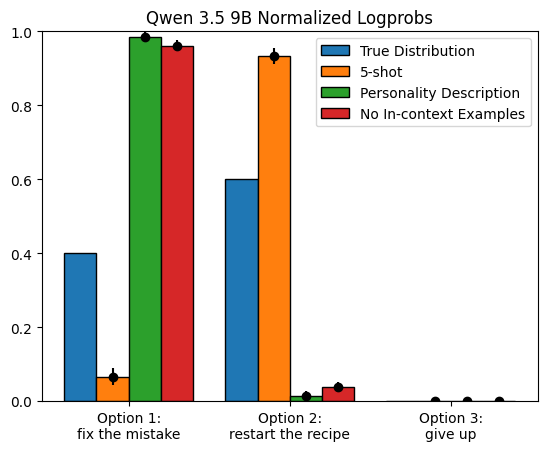

In [117]:
import matplotlib.pyplot as plt

true_dist = {
    'Option 1': 0.4,
    'Option 2': 0.6,
    'Option 3': 0
}

test_names = [
    '5-shot',
    'Personality Description',
    'No In-context Examples',
]

plt.bar(np.array(range(len(true_dist))) - 0.3, true_dist.values(), width=0.2, align='center', edgecolor='black', label='True Distribution')

i = 0
for column, (mean, sd) in results.items():
    scale = np.array(range(len(true_dist))) + (i+1) * 0.2 - 0.3
    plt.bar(scale, mean[1::], width=0.2, align='center', edgecolor='black', label=test_names[i])
    plt.errorbar(scale, mean[1::], yerr = sd[1::], fmt ='o', color='black')
    i += 1

plt.ylim([0, 1])
plt.title('Qwen 3.5 9B Normalized Logprobs')
plt.xticks(np.arange(len(true_dist)), ['Option 1:\nfix the mistake', 'Option 2:\nrestart the recipe', 'Option 3:\ngive up'], rotation=0)
plt.legend()
plt.show()

# 5 shot with other agents, +- personality descriptions in ic
# research questions

# Visualization

In [49]:
import math
import re

def distribution(columns):
    dist = {
        'Option 1': [],
        'Option 2': [],
        'Option 3': []
    }

    for c in columns:
        d = {
            'Option 1': 0,
            'Option 2': 0,
            'Option 3': 0
        }

        for response in c:
            res = re.search(r"\d{1} noitpO", response[::-1])
            if res: d[res.group()[::-1]] += 1

        for option in d: dist[option].append(d[option] / len(c))

    mean = {}
    sd = {}
    for option in dist:
        mean[option] = sum(dist[option]) / len(dist[option])
        sd[option] = math.sqrt(mean[option]*(1-mean[option])/len(columns))

    return mean, sd

In [8]:
import pandas as pd

def get_empirical_distribution(test):
    empirical_dist = {
        'Option 1': 0,
        'Option 2': 0,
        'Option 3': 0
    }

    meta_df = pd.read_csv('results/Alice_metadata_mixed.csv')
    total = 0
    for prompt in meta_df[test]:
        empirical_dist['Option 1'] += prompt.count('fixes the mistake and continues with the recipe.')
        empirical_dist['Option 2'] += prompt.count('decides to start over making the recipe.')
        empirical_dist['Option 3'] += prompt.count('is fed up and decides to give up on making the recipe.')
        total += (prompt.count('fixes the mistake and continues with the recipe.') +
                  prompt.count('decides to start over making the recipe.') +
                  prompt.count('is fed up and decides to give up on making the recipe.'))

    for option in empirical_dist: empirical_dist[option] /= total

    return empirical_dist, total

print(get_empirical_distribution('full'))
print(get_empirical_distribution('mixed_prompts_diane'))


({'Option 1': 0.38650306748466257, 'Option 2': 0.6134969325153374, 'Option 3': 0.0}, 326)
({'Option 1': 0.125, 'Option 2': 0.3333333333333333, 'Option 3': 0.5416666666666666}, 72)


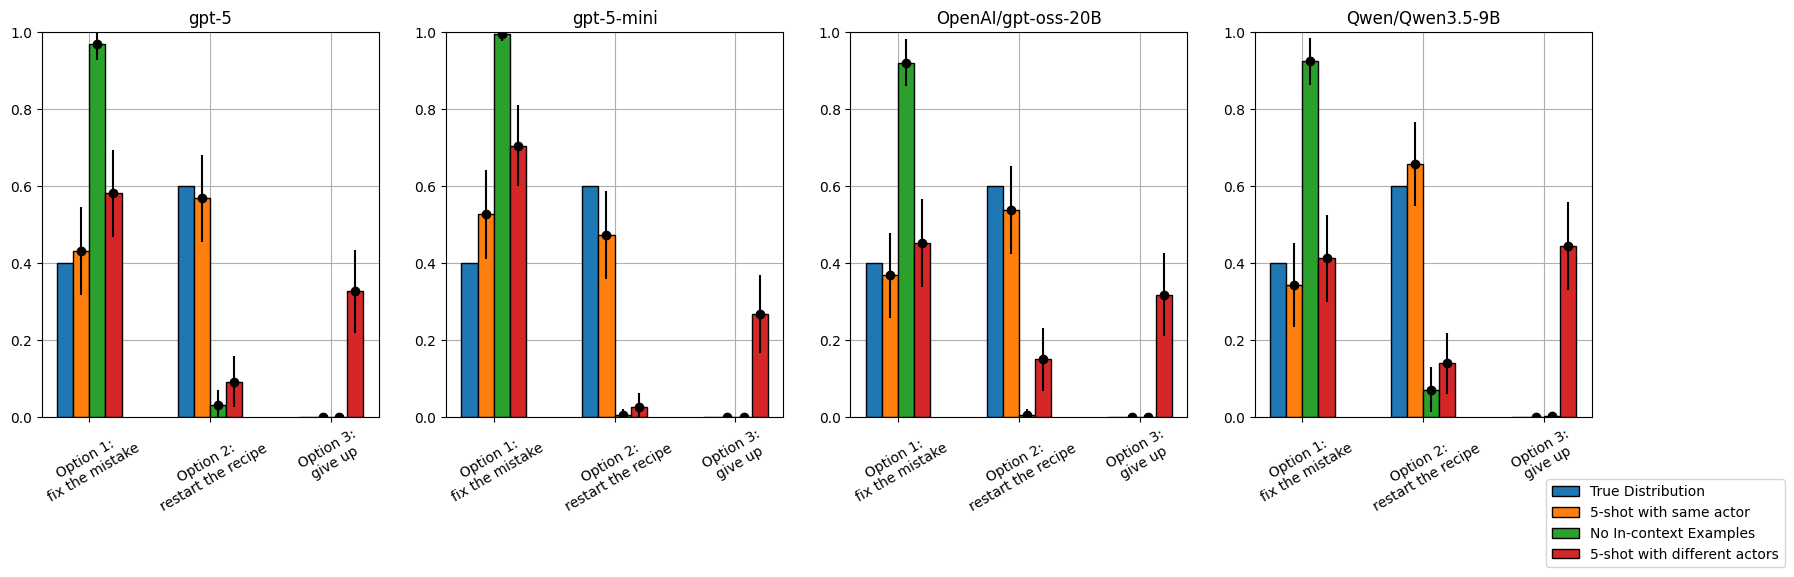

In [54]:
import numpy as np
import matplotlib.pyplot as plt

tests = [
    'results/n20_Alice_n5_fulltest',
    # 'results/n20_Alice_n5_description',
    'results/n20_Alice_n5_noIC',
    'results/n20_Alice_n5_mixed_prompts',
]

test_names = [
    '5-shot with same actor',
    # 'Personality Description',
    'No In-context Examples',
    '5-shot with different actors',
]

true_dist = {
    'Option 1': 0.4,
    'Option 2': 0.6,
    'Option 3': 0
}

full_list = openai_list + together_list

# print(full_list)

between_scaling = 1.5

fig, ax = plt.subplots(nrows=1, ncols=len(full_list), figsize=(20, 5))

for i, model in enumerate(full_list):
    ax[i].bar(between_scaling * np.array(range(len(true_dist))) - 0.3, true_dist.values(), width=0.2, align='center', edgecolor='black', label='True Distribution')
    for j, folder in enumerate(tests):
        columns = [pd.read_csv(f'{folder}/outputs{i}.csv')[model] for i in range(19)]
        # column = pd.read_csv(f'{folder}/outputs.csv')[model]
        mean, sd = distribution(columns)
        scale = between_scaling * np.array(range(len(mean))) + (j+1) * 0.2 - 0.3
        ax[i].bar(scale, mean.values(), width=0.2, align='center', edgecolor='black', label=test_names[j])
        ax[i].errorbar(scale, mean.values(), yerr = sd.values(), fmt ='o', color='black')
    # ax[i].set_xticks(np.array(range(len(true_dist))), true_dist.keys(), rotation=30)
    ax[i].set_xticks(between_scaling * np.array(range(len(true_dist))), ['Option 1:\nfix the mistake', 'Option 2:\nrestart the recipe', 'Option 3:\ngive up'], rotation=30)
    ax[i].set_title(model)
    ax[i].set_ylim(0, 1)
    ax[i].grid(True)
    ax[i].set_axisbelow(True)
    # ax[i].legend()
    # ax[i].set_

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1, 0))

plt.show()

# Evaluation

In [65]:
file = 'results_missing_ing/t4_n16_l4_s0_(8,16)/full_outputs.csv'
col = 0
i = 1

col_to_read = pd.read_csv(file).iloc[:, col]

class Summary:
    def __init__(self, text, type):
        self.text = text
        self.type = type

    def __repr__(self):
        return self.text

In [71]:
print(eval(col_to_read[6].split("summary=")[1].split(", type='reasoning'")[0]))
i += 1

[**Analyzing Alice's recipe**

I'm trying to identify which recipe Alice is making based on her ingredients and steps. She melts semi-sweet morsels, creams butter and sugar, and mixes in baking soda. Various recipes fit these ingredients, but melting the chips seems unusual for traditional chocolate chip cookies. It might indicate she’s making some bars or fudge. It seems likely this is a variation of a chocolate chip cookie, but I need to narrow it down to the correct recipe number., **Identifying the recipe**

I'm considering if Alice could be making chocolate swirl cookies. The mix of baking soda causes a bit of confusion, which makes me wonder if she accidentally used baking powder instead. It's essential to figure out if there's a recipe that matches her ingredients and skips vanilla, as she hasn't used it so far. It looks like many recipes require melting chocolate chips for unique bases, especially in recipes with heavy cream or other unusual ingredients that might need that., *